In [1]:
import os
import sys
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision.models import vit_b_16, ViT_B_16_Weights
import torchvision.transforms as transforms
from sklearn.model_selection import GroupShuffleSplit
from torch.optim.lr_scheduler import CosineAnnealingLR

from PIL import Image
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix, roc_curve
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
base_path = Path("/kaggle/input/faceswap-faces/")
batch_size = 4

In [3]:
df = pd.read_csv(base_path / "processed_metadata.csv")
df.head()

,video_id,frame_id,label,filepath
0,116_091,0,FAKE,processed_frames/faceswap/116_091/116_091_0000...
1,116_091,1,FAKE,processed_frames/faceswap/116_091/116_091_0001...
2,116_091,2,FAKE,processed_frames/faceswap/116_091/116_091_0002...
3,116_091,3,FAKE,processed_frames/faceswap/116_091/116_091_0003...
4,116_091,4,FAKE,processed_frames/faceswap/116_091/116_091_0004...


In [4]:
video_labels = df.groupby('video_id')['label'].first().reset_index()
video_labels

,video_id,label
0,000,REAL
1,000_003,FAKE
2,001,REAL
3,001_870,FAKE
4,002,REAL
...,...,...
1995,997_040,FAKE
1996,998,REAL
1997,998_561,FAKE
1998,999,REAL


In [5]:
video_labels.value_counts()

video_id  label
999_960   FAKE     1
000       REAL     1
000_003   FAKE     1
001       REAL     1
001_870   FAKE     1
                  ..
009_027   FAKE     1
010       REAL     1
010_005   FAKE     1
011       REAL     1
011_805   FAKE     1
Name: count, Length: 2000, dtype: int64

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=69)
train_idx, temp_idx = next(gss.split(video_labels, video_labels['label'], groups=video_labels['video_id']))

train_videos = video_labels.iloc[train_idx]
temp_videos = video_labels.iloc[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=69)
val_idx, test_idx = next(gss2.split(temp_videos, temp_videos['label'], groups=temp_videos['video_id']))

val_videos = temp_videos.iloc[val_idx]
test_videos = temp_videos.iloc[test_idx]

train_df = df[df['video_id'].isin(train_videos['video_id'])]
val_df = df[df['video_id'].isin(val_videos['video_id'])]
test_df = df[df['video_id'].isin(test_videos['video_id'])]

train_df

,video_id,frame_id,label,filepath
0,116_091,0,FAKE,processed_frames/faceswap/116_091/116_091_0000...
1,116_091,1,FAKE,processed_frames/faceswap/116_091/116_091_0001...
2,116_091,2,FAKE,processed_frames/faceswap/116_091/116_091_0002...
3,116_091,3,FAKE,processed_frames/faceswap/116_091/116_091_0003...
4,116_091,4,FAKE,processed_frames/faceswap/116_091/116_091_0004...
...,...,...,...,...
127983,715,59,REAL,processed_frames/original/715/715_0059.jpg
127984,715,60,REAL,processed_frames/original/715/715_0060.jpg
127985,715,61,REAL,processed_frames/original/715/715_0061.jpg
127986,715,62,REAL,processed_frames/original/715/715_0062.jpg


In [7]:
print("Train/Val/Test split summary:")
print(train_df['label'].value_counts())
print(val_df['label'].value_counts())
print(test_df['label'].value_counts())


Train/Val/Test split summary:
label
FAKE    45248
REAL    44350
Name: count, dtype: int64
label
FAKE    9600
REAL    9600
Name: count, dtype: int64
label
REAL    10038
FAKE     9152
Name: count, dtype: int64


In [8]:
train_vids = set(train_df['video_id'].unique())
val_vids = set(val_df['video_id'].unique())
test_vids = set(test_df['video_id'].unique())

print("Train∩Val:", len(train_vids & val_vids))
print("Train∩Test:", len(train_vids & test_vids))
print("Val∩Test:", len(val_vids & test_vids))

train_files = set(train_df['filepath'])
val_files   = set(val_df['filepath'])
print("Common files train/val:", len(train_files & val_files))

Train∩Val: 0
Train∩Test: 0
Val∩Test: 0
Common files train/val: 0


In [9]:
def custom_collate_fn(batch):
    imgs, labels, vids = zip(*batch)
    imgs = torch.stack(imgs)
    labels = torch.stack(labels)
    return imgs, labels, vids

In [10]:
class DeepfakeDataset(Dataset):
    def __init__(self, data, seq_length=50):
        self.df = data
        self.seq_length = seq_length
        self.videos = data['video_id'].unique()

    def __len__(self):
        return len(self.videos)

    def __getitem__(self, idx):
        vid = self.videos[idx]
        frames = self.df[self.df['video_id'] == vid]
        if len(frames) == 0:
            print(f"[WARN] Label {frames['label'][0]} Video {vid} has 0 frames in DataFrame")

        imgs = [Image.open(f"/kaggle/input/faceswap-faces/{fp}").convert('RGB') for fp in frames['filepath']]
        imgs = [self.transform(i) for i in imgs]
        imgs = torch.stack(imgs)
        imgs = self._add_padding(imgs)
        label = 1 if frames['label'].iloc[0] == 'FAKE' else 0
        vid = str(vid)
        return imgs, torch.tensor(label), vid


    def transform(self, img):
        if img.size != (224, 224):
            img = img.resize((224, 224))
        img_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomResizedCrop(224,scale=(0.8, 1.0)),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
        ])
        torch_tensor = img_transform(img)
        return torch_tensor

    def _add_padding(self, images):
        if images.size(0) > self.seq_length:
            images = images[:self.seq_length]
        padding_needed = self.seq_length - images.size(0)
        if padding_needed > 0:
            pad_tensor = torch.zeros(padding_needed, 3, 224, 224)
            images = torch.cat((images, pad_tensor), dim=0)
        return images

In [11]:
train_dataset = DeepfakeDataset(train_df, seq_length=64)
val_dataset = DeepfakeDataset(val_df, seq_length=64)
test_dataset = DeepfakeDataset(test_df, seq_length=64)


In [12]:
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle=True, num_workers=4, pin_memory=True)


In [13]:
for i, batch in enumerate(train_loader):
    try:
        imgs, labels, vids = batch
        # print(f"Batch {i}: imgs {imgs.shape}, labels {labels.shape}, vids {type(vids[0])}")
    except Exception as e:
        print(f"Error at batch {i}: {e}")
        break

In [14]:
VIT_FEATURE_DIM_MAP = {
    'vit_b_16': 768,
    'vit_s_16': 384
}

In [15]:
class MultiheadAttentionPooling(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=True, dropout=dropout)
        # learnable query token
        self.query = nn.Parameter(torch.randn(1, 1, dim))
        nn.init.normal_(self.query, std=0.02)

    def forward(self, x):
        # x: (B, T, D)
        B = x.size(0)
        query = self.query.expand(B, -1, -1)                # (B, 1, D)
        pooled, _ = self.attn(query, x, x)                  # (B, 1, D)
        return pooled.squeeze(1)                            # (B, D)

In [16]:
class DetectionModel(nn.Module):
    def __init__(
        self,
        num_classes=1,
        backbone='vit_b_16',       # 'vit_s_16' or 'vit_b_16'
        pretrained=True,
        temporal_layers=2,
        temporal_heads=4,
        hidden_dim=512,
        pool_heads=4,
        freeze_backbone=True
    ):
        super().__init__()

        self.backbone_name = backbone
        self.vit_feature_dim = VIT_FEATURE_DIM_MAP[backbone]

        # -----------------------
        # 1. Vision Transformer backbone (without head)
        # -----------------------

        weights = ViT_B_16_Weights.IMAGENET1K_V1 if pretrained else None
        self.vit = vit_b_16(weights=weights)

        # remove classification head -> get feature vector per image
        # torchvision ViT has .heads.head (or .heads depending on version). we replace with Identity.
        try:
            self.vit.heads.head = nn.Identity()
        except Exception:
            # fallback in case torchvision API differs
            if hasattr(self.vit, 'heads'):
                self.vit.heads = nn.Identity()
            else:
                raise

        if freeze_backbone:
            for p in self.vit.parameters():
                p.requires_grad = False

        # -----------------------
        # 2. Improved temporal stem (3D conv) - keeps more temporal detail but is cheap
        # -----------------------
        # Input: (B, C, T, H, W) expected after permute
        self.temporal_stem = nn.Sequential(
            # increase channels modestly, reduce temporal dimension gently
            nn.Conv3d(3, 16, kernel_size=(3, 3, 3), stride=(4, 2, 2), padding=1, bias=False),
            nn.BatchNorm3d(16),
            nn.GELU(),
            # reduce back to 3 channels (so we can reuse same pretrained ViT weights' expected input channels)
            nn.Conv3d(16, 3, kernel_size=(3, 1, 1), padding=(1, 0, 0), bias=False),
            nn.BatchNorm3d(3),
            nn.GELU(),
        )

        # -----------------------
        # 3. Positional encoding (learnable, but adaptable to variable T)
        # -----------------------
        self.max_pos_len = 256
        self.pos_encoding = nn.Parameter(torch.zeros(1, self.max_pos_len, self.vit_feature_dim))
        nn.init.normal_(self.pos_encoding, std=0.02)

        # -----------------------
        # 4. Bi-LSTM temporal encoder
        # -----------------------
        self.temporal_lstm = nn.LSTM(
            input_size=self.vit_feature_dim,
            hidden_size=hidden_dim,
            num_layers=temporal_layers,
            batch_first=True,
            dropout=0.1,
            bidirectional=True
        )
        
        # Linear projection back to ViT feature dim (for compatibility with rest of model)
        self.temporal_proj = nn.Linear(hidden_dim * 2, self.vit_feature_dim)

        # -----------------------
        # 5. Lightweight temporal conv (depthwise) to model local motion in feature space
        # -----------------------
        # Using Grouped conv with groups=dim -> depthwise 1D conv along time
        self.temporal_conv = nn.Conv1d(
            in_channels=self.vit_feature_dim,
            out_channels=self.vit_feature_dim,
            kernel_size=3,
            padding=1,
            groups=self.vit_feature_dim,
            bias=False
        )

        # -----------------------
        # 6. Pooling (attention + mean fusion)
        # -----------------------
        self.pool = MultiheadAttentionPooling(self.vit_feature_dim, num_heads=pool_heads)

        # -----------------------
        # 7. Classifier (logits) — use BCEWithLogitsLoss in training
        # -----------------------
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.vit_feature_dim),
            nn.Dropout(0.4),
            nn.Linear(self.vit_feature_dim, num_classes)   # num_classes=1 -> binary logit
        )

    def unfreeze_backbone_layers(self, last_n=4):
        # unfreeze last_n encoder layers from the ViT encoder
        enc_layers = list(self.vit.encoder.layers)
        for layer in enc_layers[-last_n:]:
            for p in layer.parameters():
                p.requires_grad = True

    def extract_vit_features(self, frames):
        # frames: tensor (N, 3, H, W) -> returns (N, D)
        with torch.no_grad():
            feats = self.vit(frames)
        return feats
        
    def forward(self, x):
        B, T, C, H_in, W_in = x.shape

        # 1) temporal stem expects (B, C, T, H, W)
        x = x.permute(0, 2, 1, 3, 4)        # (B, C, T, H, W)
        x = self.temporal_stem(x)           # (B, 3, T', H', W')
        # after stem, permute to (B, T', C, H', W')
        x = x.permute(0, 2, 1, 3, 4)
        B2, T2, C2, H2, W2 = x.shape

        # 2) resize frames to ViT input size (224x224) in a batched manner
        # reshape to (B*T, C, H, W) then interpolate
        frames = x.reshape(B2 * T2, C2, H2, W2)
        frames = F.interpolate(frames, size=(224, 224), mode='bilinear', align_corners=False)

        # 3) pass through ViT backbone to get (B*T, D)
        vit_out = self.vit(frames)                      # (B*T, D)
        D = vit_out.shape[-1]
        vit_feats = vit_out.view(B2, T2, D)             # (B, T, D)

        # 4) add positional encoding (interpolate if T2 > max_pos_len or <)
        if T2 <= self.max_pos_len:
            pos = self.pos_encoding[:, :T2, :]
        else:
            # interpolate positional encodings along time dimension
            pos = F.interpolate(self.pos_encoding.permute(0, 2, 1), size=T2, mode='linear', align_corners=False)
            pos = pos.permute(0, 2, 1)
        vit_feats = vit_feats + pos

        # 5) local temporal conv (depthwise) in feature space
        # Conv1d expects (B, D, T)
        vit_feats = vit_feats.transpose(1, 2)          # (B, D, T)
        vit_feats = self.temporal_conv(vit_feats)       # (B, D, T)
        vit_feats = vit_feats.transpose(1, 2)           # (B, T, D)

        # 6) optional stochastic frame dropout during training for robustness
        if self.training:
            # drop 10% of frames randomly (works as data augmentation)
            drop_prob = 0.1
            mask = (torch.rand(B2, T2, device=vit_feats.device) > drop_prob).float().unsqueeze(-1)
            # ensure not all zeros per sample:
            # at least keep one frame: (rarely necessary, but safe)
            vit_feats = vit_feats * mask

        # 7) temporal transformer
        # temporal_feats = self.temporal_transformer(vit_feats)   # (B, T, D)
        lstm_out, _ = self.temporal_lstm(vit_feats)  # (B, T, 2*hidden_dim)
        temporal_feats = self.temporal_proj(lstm_out)  # (B, T, D)


        # 8) pooling fusion: attention pooling + mean pooling
        attn_context = self.pool(temporal_feats)               # (B, D)
        mean_context = temporal_feats.mean(dim=1)              # (B, D)
        context = 0.6 * attn_context + 0.4 * mean_context      # weighted fusion

        # 9) classification logits
        logits = self.classifier(context)                      # (B, num_classes)
        return logits


In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device: ", device)

model = DetectionModel()
if device == "cuda":
    model = model.to(device)

Using device:  cuda


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:01<00:00, 198MB/s]


In [18]:
num_epochs = 50
criterion = nn.BCEWithLogitsLoss(pos_weight=None, reduction='mean')  # More stable for binary tasks
optimizer = optim.AdamW([
    {"params": model.vit.encoder.layers[-1].parameters(), "lr": 1e-5},
    {"params": model.temporal_stem.parameters(), "lr": 1e-4},
    {"params": model.pool.parameters(), "lr": 1e-4},
    {"params": model.temporal_lstm.parameters(), "lr": 1e-4},
    {"params": model.classifier.parameters(), "lr": 5e-4},
], lr=1e-4, weight_decay=0.001)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr = 1e-4, steps_per_epoch=len(train_loader), epochs=num_epochs)

In [19]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, verbose=False):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float('inf')

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), 'checkpoint.pt')
        self.val_loss_min = val_loss


In [20]:
scaler = torch.amp.GradScaler('cuda')
early_stopping = EarlyStopping(patience=7, verbose=True)

train_losses = []
val_losses = []
val_accuracies = []


for epoch in range(num_epochs):
    print("\n" + "="*50)
    print(f"Running Epoch: {epoch+1}/{num_epochs}")
    print("="*50)
    
    # ------------------
    # 1. Training Phase (Sequence-level)
    # ------------------
    model.train()
    train_loss = 0
    
    # imgs shape: (B, T, C, H, W), labels shape: (B), _ (vids)
    for imgs, labels, _ in tqdm(train_loader, desc="Training", file=sys.stdout):
        
        # Move video sequence batch to device
        imgs = imgs.to(device)
        labels = labels * 0.9 + 0.05
        
        # Move and format labels: (B) -> (B, 1) float for BCEWithLogitsLoss
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        
        # Autocast enables mixed precision for the forward pass
        with torch.amp.autocast(device):
            # Forward pass: model expects (B, T, C, H, W) and outputs (B, 1)
            outputs = model(imgs) 
            loss = criterion(outputs, labels)

        # Scale loss, backpropagate, and update
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    
    # Step the learning rate scheduler after the epoch
    
    # ------------------
    # 2. Validation Phase (Sequence-level)
    # ------------------
    model.eval()
    per_video_rows = []
    val_loss = 0
    
    with torch.no_grad(), torch.amp.autocast(device):
        for imgs, labels, vids in val_loader:
            B, _, _, _, _ = imgs.shape
            
            # Pass the entire sequence batch (B, T, C, H, W) to the model
            imgs = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            # Forward pass, outputs are logits (B, 1)
            outputs = model(imgs) 
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            
            # Apply sigmoid to get video prediction probabilities and flatten (B,)
            video_preds = torch.sigmoid(outputs).cpu().numpy().ravel()
            
            for i in range(B):
                per_video_rows.append({
                    'video_id': vids[i],
                    # Direct score from the model's output
                    'pred': float(video_preds[i]), 
                    'label': int(labels[i].item())
                })
    avg_val_loss = val_loss / len(val_loader)
    
    # --- Evaluation ---
    video_df_pred = pd.DataFrame(per_video_rows)
    # Only keep one prediction per video, although the current loader only provides one.
    video_df_pred = video_df_pred.drop_duplicates(subset='video_id') 
    
    # Ensure there are enough samples and both classes for meaningful metrics
    if len(video_df_pred) > 1 and len(video_df_pred['label'].unique()) > 1:
        auc = roc_auc_score(video_df_pred['label'], video_df_pred['pred'])
    else:
        auc = 0.0
        print("Warning: Insufficient data for AUC calculation.")

    acc = accuracy_score(video_df_pred['label'], (video_df_pred['pred'] > 0.5).astype(int))

    early_stopping(avg_val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

    if epoch == 3:  # Unfreeze after 3 epochs of stable training
        model.unfreeze_backbone_layers()
        optimizer = optim.AdamW([
            {"params": model.vit.encoder.layers[-1].parameters(), "lr": 1e-5},
            {"params": model.vit.encoder.layers[-2].parameters(), "lr": 1e-5},
            {"params": model.vit.encoder.layers[-3].parameters(), "lr": 1e-5},
            {"params": model.vit.encoder.layers[-4].parameters(), "lr": 1e-5},
            {"params": model.temporal_stem.parameters(), "lr": 1e-4},
            {"params": model.pool.parameters(), "lr": 1e-4},
            {"params": model.temporal_lstm.parameters(), "lr": 1e-4},
            {"params": model.classifier.parameters(), "lr": 5e-4}
        ], lr=1e-4, weight_decay=0.001)
    
        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=1e-4,
            steps_per_epoch=len(train_loader),
            epochs=num_epochs
        )
    
        print("🔄 Optimizer updated after unfreezing layers.")



    train_losses.append(avg_train_loss) 
    val_losses.append(avg_val_loss)
    val_accuracies.append(acc)

    # ------------------
    # 3. Epoch Summary
    # ------------------
    print("\n" + "*"*60)
    print(f"Epoch {epoch+1} Summary:")
    print(f"| Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val AUC: {auc:.4f} | Val Acc: {acc:.4f} |")
    # print("\nPrediction Score Distribution:")
    # print(video_df_pred['pred'].describe().to_string())
    print("\n" + "*"*60)


Running Epoch: 1/50
Training:   0%|          | 1/350 [00:06<34:54,  6.00s/it]

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Training: 100%|██████████| 350/350 [04:55<00:00,  1.19it/s]
Validation loss decreased (inf --> 0.677331). Saving model...

************************************************************
Epoch 1 Summary:
| Train Loss: 0.7160 | Val Loss: 0.6773 | Val AUC: 0.6094 | Val Acc: 0.5933 |

************************************************************

Running Epoch: 2/50
Training: 100%|██████████| 350/350 [04:53<00:00,  1.19it/s]
Validation loss decreased (0.677331 --> 0.663738). Saving model...

************************************************************
Epoch 2 Summary:
| Train Loss: 0.6984 | Val Loss: 0.6637 | Val AUC: 0.6522 | Val Acc: 0.6033 |

************************************************************

Running Epoch: 3/50
Training: 100%|██████████| 350/350 [04:53<00:00,  1.19it/s]
Validation loss decreased (0.663738 --> 0.651606). Saving model...

************************************************************
Epoch 3 Summary:
| Train Loss: 0.6781 | Val Loss: 0.6516 | Val AUC: 0.6580 | Val A


************************************************************
Test Summary:
| Test Loss: 0.2309 | Test AUC: 0.9754 | Test Acc: 0.9200 |

Classification Report:
              precision    recall  f1-score   support

        Real       0.89      0.97      0.93       157
        Fake       0.96      0.87      0.91       143

    accuracy                           0.92       300
   macro avg       0.93      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300

************************************************************


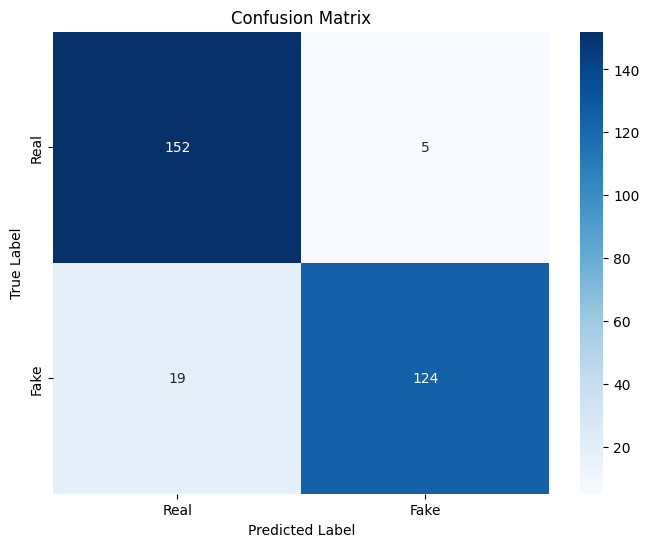

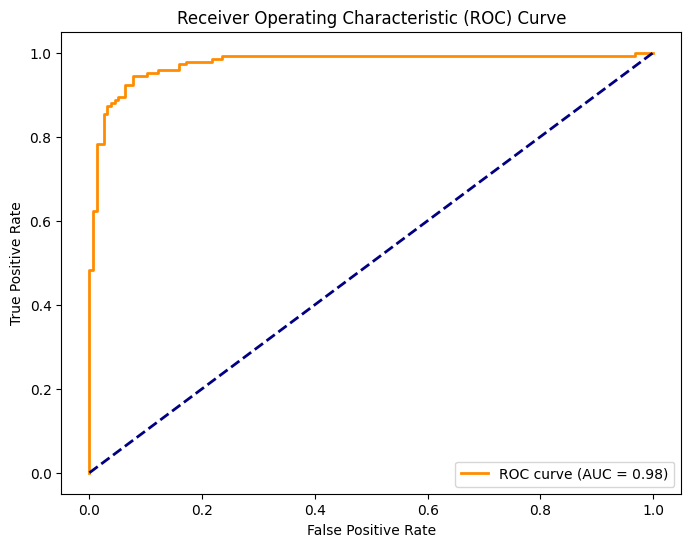

In [21]:
def test_model(model):
    model.eval()
    per_video_rows = []
    test_loss = 0
    
    with torch.no_grad():
        for imgs, labels, vids in test_loader:
            B, _, _, _, _ = imgs.shape
            
            imgs = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            
            video_preds = torch.sigmoid(outputs).cpu().numpy().ravel()
            
            for i in range(B):
                per_video_rows.append({
                    'video_id': vids[i],
                    'pred': float(video_preds[i]),
                    'label': int(labels[i].item())
                })
    
    avg_test_loss = test_loss / len(test_loader)
    
    # --- Evaluation ---
    video_df_pred = pd.DataFrame(per_video_rows).drop_duplicates(subset='video_id')
    
    if len(video_df_pred) > 1 and len(video_df_pred['label'].unique()) > 1:
        auc = roc_auc_score(video_df_pred['label'], video_df_pred['pred'])
    else:
        auc = 0.0
        print("Warning: Insufficient data for AUC calculation.")

    true_labels = video_df_pred['label']
    binary_predictions = (video_df_pred['pred'] > 0.5).astype(int)
    acc = accuracy_score(true_labels, binary_predictions)
    report = classification_report(true_labels, binary_predictions, target_names=['Real', 'Fake'])

    # --- Print Summary ---
    print("\n" + "*"*60)
    print("Test Summary:")
    print(f"| Test Loss: {avg_test_loss:.4f} | Test AUC: {auc:.4f} | Test Acc: {acc:.4f} |")
    print("\nClassification Report:")
    print(report)
    print("*"*60)

    # --- Plot Confusion Matrix ---
    cm = confusion_matrix(true_labels, binary_predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # --- Plot ROC Curve ---
    fpr, tpr, _ = roc_curve(true_labels, video_df_pred['pred'])
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

# --- Run the test function ---
test_model(model)

In [22]:
torch.save(model.state_dict(), "model_state.pth")


************************************************************
Test Summary:
| Test Loss: 0.2173 | Test AUC: 0.9779 | Test Acc: 0.9233 |

Classification Report:
              precision    recall  f1-score   support

        Real       0.92      0.94      0.93       157
        Fake       0.93      0.91      0.92       143

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300

************************************************************


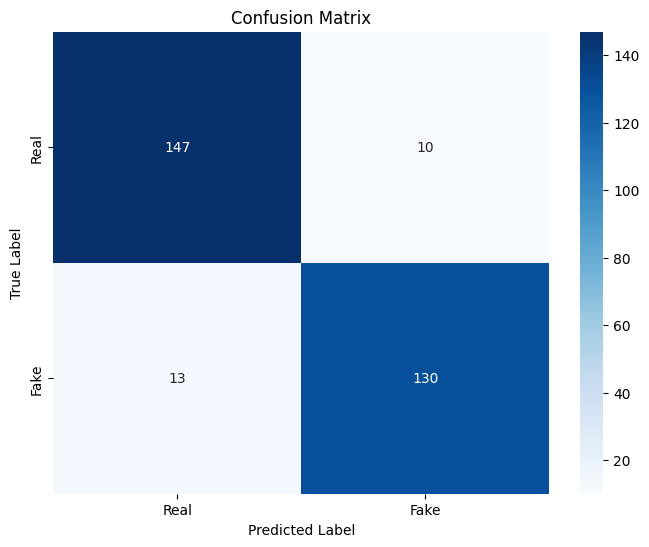

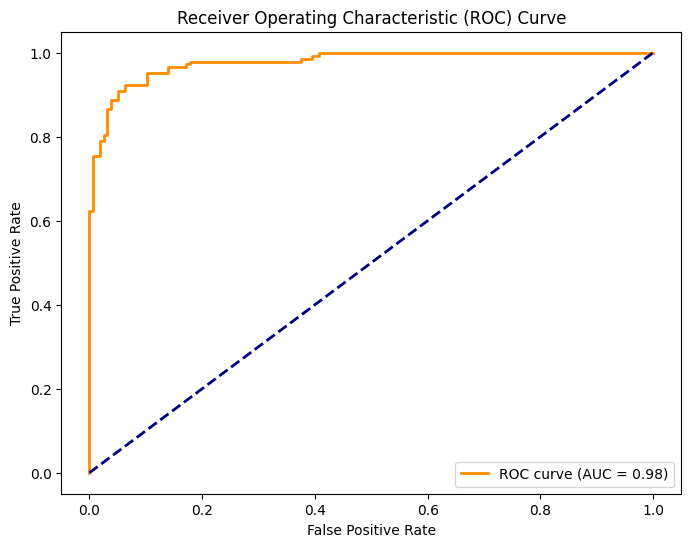

In [23]:
# Create a new instance of the model
model2 = DetectionModel()

# Load the saved state dictionary
checkpoint_dict = torch.load("checkpoint.pt")

# Load the state dict into the model IN-PLACE
model2.load_state_dict(checkpoint_dict)

# Now, move the model to the correct device
if device == "cuda":
    model2 = model2.to(device)

# Test the model
test_model(model2)

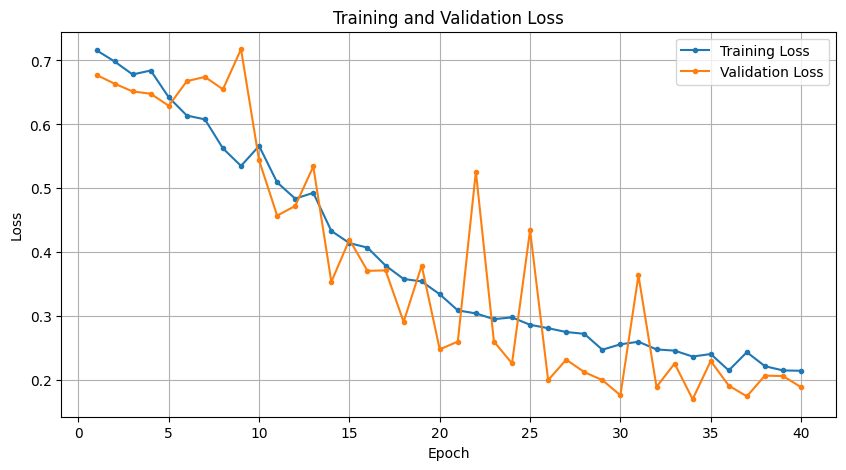

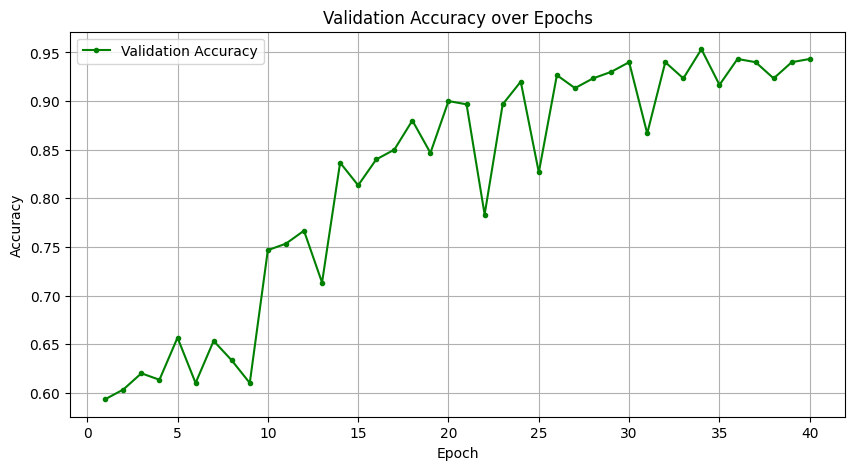

In [24]:
import matplotlib.pyplot as plt

num_epochs_run = len(train_losses) 
epochs = range(1, num_epochs_run + 1) # X-axis data

# Plot 1: Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label='Training Loss', marker='.')
plt.plot(epochs, val_losses, label='Validation Loss', marker='.')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Accuracy Curve
plt.figure(figsize=(10, 5))
plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='green', marker='.')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()